In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib as plt

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train= pd.read_csv('/kaggle/input/titanic/train.csv')
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.shape

(891, 12)

In [4]:
test=pd.read_csv('/kaggle/input/titanic/test.csv')
test1=pd.read_csv('/kaggle/input/titanic/test.csv')

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
test.shape

(418, 11)

In [6]:
train.head()
#setting 'PassengerId' as Index
train.set_index(['PassengerId'],inplace=True)
test.set_index(['PassengerId'],inplace=True)
test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
train.isnull().sum()


Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [8]:
test.isnull().sum()


Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64

In [9]:
train.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

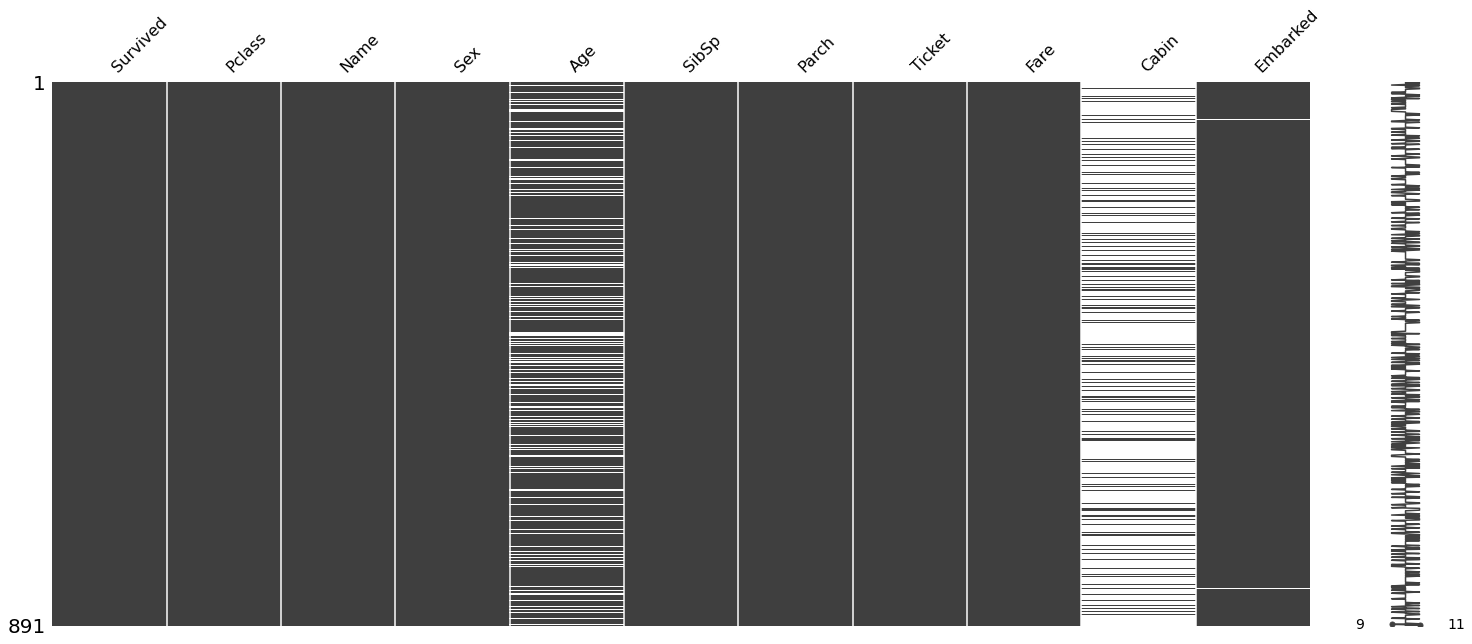

In [10]:
#missing value treatment

#first lets get a visual on these
import missingno as mn
mn.matrix(train)

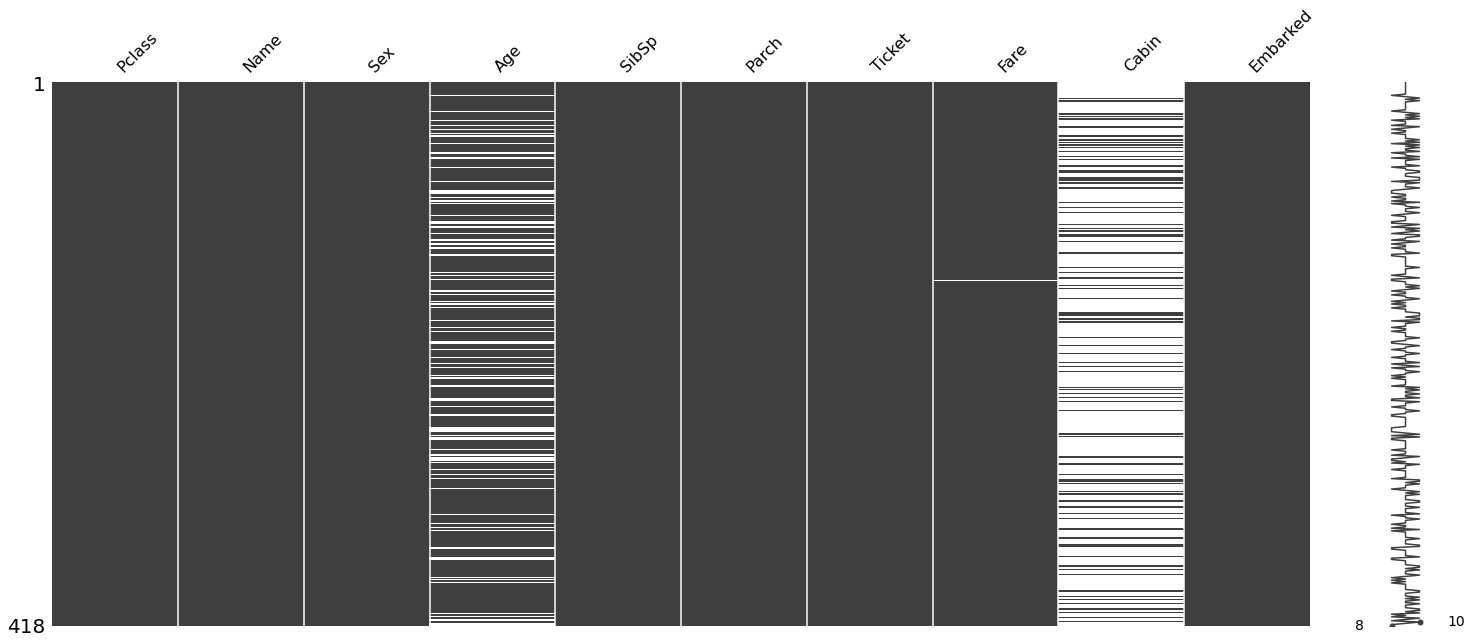

In [11]:
mn.matrix(test)

In [12]:
#lets start imputing 'Age'
train['Age2']=train['Age'].fillna(train.Age.median())
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age2
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0


In [13]:
test['Age_test']=test['Age'].fillna(test.Age.median())
train.head()
test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_test
PassengerId,,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,34.5
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,47.0
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,62.0
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,27.0
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,22.0


In [14]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
Age2          0
dtype: int64

In [15]:
test.isnull().sum()

Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
Age_test      0
dtype: int64

In [16]:
#using fillna to fill 'Embarked' section values
train.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [17]:
#S is the dominant column
train.Embarked.fillna('S',inplace=True)
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
Age2          0
dtype: int64

In [18]:
#filling 'Fare' with mean
test.Fare.fillna(test.Fare.mean(),inplace=True)
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
Age2          0
dtype: int64

In [19]:
#'cabin' contains more than 80% missing values, so dropping that as well as 'age' from before.
train.drop(['Age','Cabin'],axis=1,inplace=True)
test.drop(['Age','Cabin'],axis=1,inplace=True)
train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
Age2        0
dtype: int64

In [20]:
test.isnull().sum()

Pclass      0
Name        0
Sex         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
Age_test    0
dtype: int64

In [21]:
#no more missing values, now lets handle categorical data.
#transforming 'Sex' from object to int
train['Sex']=train.Sex.apply(lambda x:0 if x=='female' else 1)
test['Sex']=test.Sex.apply(lambda x:0 if x=='female' else 1)
test.Sex.head()

PassengerId
892    1
893    0
894    1
895    1
896    0
Name: Sex, dtype: int64

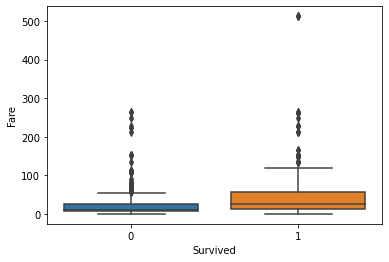

In [22]:
#removing outliers from 'Fare'
sns.boxplot('Survived','Fare',data=train)

In [23]:
train['Fare']=train[train['Fare']<=400]
test['Fare']=test[test['Fare']<=400]

In [24]:
#feature_engineering
train['family_size']=train['SibSp']+train['Parch']+1 #+1 if alone
test['family_size']=test['SibSp']+test['Parch']+1 #+1 if alone

train.head()

,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked,Age2,family_size
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",1,1,0,A/5 21171,0,S,22.0,2
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,0,PC 17599,1,C,38.0,2
3,1,3,"Heikkinen, Miss. Laina",0,0,0,STON/O2. 3101282,1,S,26.0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,0,113803,1,S,35.0,2
5,0,3,"Allen, Mr. William Henry",1,0,0,373450,0,S,35.0,1


In [25]:
test.head()

,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked,Age_test,family_size
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",1,0,0,330911,3,Q,34.5,1
893,3,"Wilkes, Mrs. James (Ellen Needs)",0,1,0,363272,3,S,47.0,2
894,2,"Myles, Mr. Thomas Francis",1,0,0,240276,2,Q,62.0,1
895,3,"Wirz, Mr. Albert",1,0,0,315154,3,S,27.0,1
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,1,1,3101298,3,S,22.0,3


In [26]:
#creating categories acc. to family_size
def family_group(size):
    a=''
    if(size<=1):
        a='alone'
    elif(size<=4):
        a='small'
    else:
        a='large'
    return a
train['family_group']=train.family_size.map(family_group)
test['family_group']=test.family_size.map(family_group)

train.head()

,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked,Age2,family_size,family_group
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",1,1,0,A/5 21171,0,S,22.0,2,small
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,0,PC 17599,1,C,38.0,2,small
3,1,3,"Heikkinen, Miss. Laina",0,0,0,STON/O2. 3101282,1,S,26.0,1,alone
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,0,113803,1,S,35.0,2,small
5,0,3,"Allen, Mr. William Henry",1,0,0,373450,0,S,35.0,1,alone


In [27]:
#creating categories acc. to age
def age_group(age):
    a=''
    if(age<=1):
        a='infant'
    elif(age<=4):
        a='small'
    elif(age<=14):
        a='child'
    elif(age<=25):
        a='young'
    elif(age<=40):
        a='adult'
    elif(age<=55):
        a='mid-age'
    else:
        a='old'
    return a
train['age_group']=train.Age2.map(age_group)
test['age_group']=test.Age_test.map(age_group)
train.age_group.value_counts()


adult      440
young      224
mid-age    110
old         40
child       37
small       26
infant      14
Name: age_group, dtype: int64

In [28]:
#creating categories acc. to fare: fare per person
train['fare_per_person']=train['Fare']/train['family_size']
test['fare_per_person']=test['Fare']/test['family_size']

def fare_group(fare):
    a=''
    if(fare<=4):
        a='very-low'
    elif(fare<=10):
        a='low'
    elif(fare<=20):
        a='mid'
    elif(fare<=45):
        a='high'
    else:
        a='very-high'
    return a
train['fare_group']=train.fare_per_person.map(fare_group)
test['fare_group']=test.fare_per_person.map(fare_group)

test.fare_group.value_counts()

very-low     417
very-high      1
Name: fare_group, dtype: int64

In [29]:
#creating dummy variables
train=pd.get_dummies(train,columns=['Embarked','family_group','age_group','fare_group'],drop_first=True)
test=pd.get_dummies(test,columns=['Embarked','family_group','age_group','fare_group'],drop_first=True)

#will do onehotencoding

In [30]:
train.shape
test.shape

(418, 21)

In [31]:
#dropping unnecessary columns
train.drop(['Name','Ticket','Fare','Age2','fare_per_person','family_size'],axis=1,inplace=True)# Fare and fare-per_person are replaced by fare_group, age by age_group, family by family_group
test.drop(['Name','Ticket','Fare','Age_test','fare_per_person','family_size'],axis=1,inplace=True)
test.head()

,Pclass,Sex,SibSp,Parch,Embarked_Q,Embarked_S,family_group_large,family_group_small,age_group_child,age_group_infant,age_group_mid-age,age_group_old,age_group_small,age_group_young,fare_group_very-low
PassengerId,,,,,,,,,,,,,,,
892,3,1,0,0,1,0,0,0,0,0,0,0,0,0,1
893,3,0,1,0,0,1,0,1,0,0,1,0,0,0,1
894,2,1,0,0,1,0,0,0,0,0,0,1,0,0,1
895,3,1,0,0,0,1,0,0,0,0,0,0,0,0,1
896,3,0,1,1,0,1,0,1,0,0,0,0,0,1,1


In [32]:
X=train.drop('Survived',1)
y=train['Survived']


from xgboost import XGBClassifier
xgb=XGBClassifier()

from sklearn.model_selection import cross_val_score
score = cross_val_score(xgb, X, y, n_jobs=1, scoring= 'accuracy')
print(score)
round(np.mean(score)*100, 2)

[0.75418994 0.80898876 0.81460674 0.78651685 0.80898876]


79.47

In [33]:
test.head()

,Pclass,Sex,SibSp,Parch,Embarked_Q,Embarked_S,family_group_large,family_group_small,age_group_child,age_group_infant,age_group_mid-age,age_group_old,age_group_small,age_group_young,fare_group_very-low
PassengerId,,,,,,,,,,,,,,,
892,3,1,0,0,1,0,0,0,0,0,0,0,0,0,1
893,3,0,1,0,0,1,0,1,0,0,1,0,0,0,1
894,2,1,0,0,1,0,0,0,0,0,0,1,0,0,1
895,3,1,0,0,0,1,0,0,0,0,0,0,0,0,1
896,3,0,1,1,0,1,0,1,0,0,0,0,0,1,1


In [34]:
xgb=XGBClassifier()
xgb.fit(X, y)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [35]:
#test_data = test.drop(['PassengerId'], axis=1).copy()
prediction = xgb.predict(test)
print(prediction)
print(len(prediction))

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0
 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1
 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0
 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 0 0
 0 1 1 1 1 0 0 1 0 0 1]
418


In [36]:
submission = pd.DataFrame({
        "PassengerId": test1['PassengerId'],
        "Survived": prediction
    })

submission.to_csv('submission.csv', index=False)

submission = pd.read_csv('submission.csv')

> > <a href="./submission.csv"> Download File </a>